This section sets up the Python environment for the project. 
The required libraries are imported and a connection to the PostgreSQL database is established. 
This allows the notebook to interact with the database and store cleaned datasets later in the workflow.

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

conn = psycopg2.connect(
host="localhost",
database="nfl_stats",
user="postgres",
password="buddy7up23",
port="5432"
)
print("Connected to PostgreSQL successfully!")



Connected to PostgreSQL successfully!


In [2]:
cursor = conn.cursor()
cursor.execute("SELECT current_database();")
print("Connected to database:", cursor.fetchone())

Connected to database: ('nfl_stats',)


In [3]:
cursor.execute("SELECT version();")
print(cursor.fetchone())

('PostgreSQL 18.3 on x86_64-apple-darwin24.6.0, compiled by Apple clang version 17.0.0 (clang-1700.6.3.2), 64-bit',)


In [4]:
import os
print(os.getcwd())

/Users/jadyn


In [5]:
df = pd.read_csv("/Users/jadyn/Desktop/Databases class/nfl-team-analysis/data/Nflteam_stats_2003_2023.csv")

The dataset used in this project contains NFL team statistics from the 2003–2023 seasons. 
Each row represents a team’s performance during a specific season and includes statistics such as wins, losses, points scored, yards gained, turnovers, and offensive production metrics.

This dataset will be used to explore the relationship between offensive performance and team success.

Before performing any analysis or loading the dataset into PostgreSQL, the data must first be inspected and cleaned.

The cleaning process ensures that the dataset is consistent, readable, and ready for analysis. In this section, the dataset is examined to understand its structure, including the number of rows, columns, and data types.

Next, the column names are standardized by removing extra spaces, converting all text to lowercase, and replacing spaces with underscores. This step helps ensure the column names are compatible with Python and SQL operations later in the project.

In [6]:
print("Before Cleaning")
display(df.head())
df.info()

Before Cleaning


,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,...,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,...,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,...,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
3,2003,New York Jets,6,10,0.375,283,299,-16,-1.0,16,...,8,4.0,78,69,550,15,32.4,11.8,-107.89,NaN
4,2003,Baltimore Ravens,10,6,0.625,391,281,110,6.9,16,...,18,4.8,115,126,970,23,31.8,16.6,-220.50,NaN


<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  672 non-null    int64  
 1   team                  672 non-null    str    
 2   wins                  672 non-null    int64  
 3   losses                672 non-null    int64  
 4   win_loss_perc         672 non-null    float64
 5   points                672 non-null    int64  
 6   points_opp            672 non-null    int64  
 7   points_diff           672 non-null    int64  
 8   mov                   352 non-null    float64
 9   g                     672 non-null    int64  
 10  total_yards           672 non-null    int64  
 11  plays_offense         672 non-null    int64  
 12  yds_per_play_offense  672 non-null    float64
 13  turnovers             672 non-null    int64  
 14  fumbles_lost          672 non-null    int64  
 15  first_down            672 non-null

In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned Column Names:")
print(df.columns)

Cleaned Column Names:
Index(['year', 'team', 'wins', 'losses', 'win_loss_perc', 'points',
       'points_opp', 'points_diff', 'mov', 'g', 'total_yards', 'plays_offense',
       'yds_per_play_offense', 'turnovers', 'fumbles_lost', 'first_down',
       'pass_cmp', 'pass_att', 'pass_yds', 'pass_td', 'pass_int',
       'pass_net_yds_per_att', 'pass_fd', 'rush_att', 'rush_yds', 'rush_td',
       'rush_yds_per_att', 'rush_fd', 'penalties', 'penalties_yds', 'pen_fd',
       'score_pct', 'turnover_pct', 'exp_pts_tot', 'ties'],
      dtype='str')


In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
year                      0
team                      0
wins                      0
losses                    0
win_loss_perc             0
points                    0
points_opp                0
points_diff               0
mov                     320
g                         0
total_yards               0
plays_offense             0
yds_per_play_offense      0
turnovers                 0
fumbles_lost              0
first_down                0
pass_cmp                  0
pass_att                  0
pass_yds                  0
pass_td                   0
pass_int                  0
pass_net_yds_per_att      0
pass_fd                   0
rush_att                  0
rush_yds                  0
rush_td                   0
rush_yds_per_att          0
rush_fd                   0
penalties                 0
penalties_yds             0
pen_fd                    0
score_pct                 0
turnover_pct              0
exp_pts_tot               0
ties                 

In [9]:
df = df.drop_duplicates()
print("Dataset size after removing duplicates:", df.shape)

Dataset size after removing duplicates: (672, 35)


In [10]:
df.to_csv(
"/Users/jadyn/Desktop/Databases class/nfl-team-analysis/data/nfl_team_stats_cleaned.csv",
index=False
)

print("Cleaned CSV file saved successfully!")

Cleaned CSV file saved successfully!


After cleaning the dataset, a new CSV file is created to store the processed data. 
This cleaned dataset will be used for loading the data into the PostgreSQL database 
and for further analysis in the project.

Section 3 – PostgreSQL Setup & Load, I am making 3 additional tables

In [ ]:
cursor.execute("""
CREATE TABLE teams (
    team_id SERIAL PRIMARY KEY,
    team_name TEXT UNIQUE
);
""")

conn.commit()
print("Teams table created successfully!")

In [23]:
conn.rollback()
print("Transaction reset")

Transaction reset


Creating the Teams Table

The teams table stores all the NFL teams in one place.
Each team gets its own ID, and the name is stored without duplicates. This helps keep things organized and makes it easier to connect teams to their stats later on.

In [ ]:
cursor.execute("SELECT * FROM teams;")
print(cursor.fetchall())

In [ ]:
teams = df["team"].unique()

Inserting Teams into the Database

This step adds each team into the table using a loop.
It also prevents duplicates, and `conn.commit()` saves everything.

In [ ]:
for team in teams:
    cursor.execute(
        "INSERT INTO teams (team_name) VALUES (%s) ON CONFLICT DO NOTHING;",
        (team,)
    )

conn.commit()
print("Teams inserted successfully!")

In [ ]:
cursor.execute("DROP TABLE IF EXISTS seasons;")

cursor.execute("""
CREATE TABLE seasons (
    season_id SERIAL PRIMARY KEY,
    year INT,
    team_id INT REFERENCES teams(team_id),
    wins INT,
    losses INT,
    win_loss_perc FLOAT,
    ties INT
);
""")

conn.commit()
print("Seasons table created successfully!")

This step creates the seasons table.
The seasons table stores each team's season information, such as the year, wins, losses, win percentage, and ties. The team_id column is a foreign key that connects each season record back to the correct team in the teams table.

In [ ]:
conn.rollback()
print("Transaction reset")

In [ ]:
cursor.execute("SELECT * FROM seasons;")
print(cursor.fetchall())

In [ ]:
df["ties"] = df["ties"].fillna(0).astype(int)

In [ ]:
for _, row in df.iterrows():
    cursor.execute(
        "SELECT team_id FROM teams WHERE team_name = %s;",
        (row["team"],)
    )
    team_id = cursor.fetchone()[0]

    cursor.execute("""
        INSERT INTO seasons (year, team_id, wins, losses, win_loss_perc, ties)
        VALUES (%s, %s, %s, %s, %s, %s);
    """, (
        int(row["year"]),
        int(team_id),
        int(row["wins"]),
        int(row["losses"]),
        float(row["win_loss_perc"]),
        int(row["ties"])
    ))

conn.commit()
print("Season data inserted successfully!")

In [ ]:
cursor.execute("""
SELECT s.year, t.team_name, s.wins, s.losses
FROM seasons s
JOIN teams t ON s.team_id = t.team_id
LIMIT 5;
""")

print(cursor.fetchall())

This query joins the seasons table and teams table using team_id.
It is used to make sure both tables are connected correctly and that data can be combined from both tables.


Making my third and final table, This table stores the offensive stats for each team season.

The season_id column connects this table back to the seasons table. This keeps the offensive stats separate from the team and season information while still allowing the tables to be joined together.

In [ ]:
cursor.execute("DROP TABLE IF EXISTS offensive_stats;")

cursor.execute("""
CREATE TABLE offensive_stats (
    offense_id SERIAL PRIMARY KEY,
    season_id INT REFERENCES seasons(season_id),
    points INT,
    total_yards INT,
    plays_offense INT,
    yds_per_play_offense FLOAT,
    turnovers INT,
    pass_yds INT,
    pass_td INT,
    rush_yds INT,
    rush_td INT
);
""")

conn.commit()
print("Offensive stats table created successfully!")

This step inserts offensive statistics for each team season into the offensive_stats table.

In [ ]:
for _, row in df.iterrows():
    # get season_id from seasons table
    cursor.execute("""
        SELECT season_id FROM seasons
        WHERE year = %s AND team_id = (
            SELECT team_id FROM teams WHERE team_name = %s
        );
    """, (int(row["year"]), row["team"]))

    season_id = cursor.fetchone()[0]

    # insert into offensive_stats table
    cursor.execute("""
        INSERT INTO offensive_stats (
            season_id, points, total_yards, plays_offense,
            yds_per_play_offense, turnovers, pass_yds, pass_td,
            rush_yds, rush_td
        )
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
    """, (
        season_id,
        int(row["points"]),
        int(row["total_yards"]),
        int(row["plays_offense"]),
        float(row["yds_per_play_offense"]),
        int(row["turnovers"]),
        int(row["pass_yds"]),
        int(row["pass_td"]),
        int(row["rush_yds"]),
        int(row["rush_td"])
    ))

conn.commit()
print("Offensive stats inserted successfully!")

This code loops through each row in the dataset.
For each row, it finds the correct season_id by matching the team and year.
Then, it inserts the offensive statistics into the offensive_stats table.
This connects all offensive data to the correct team and season.

In [ ]:
cursor.execute("SELECT * FROM offensive_stats LIMIT 5;")
print(cursor.fetchall())

Section 4 – SQL Insights

In [ ]:
# Query 1 (offense vs wins)
#Does a high scoring offense mean a good season?

cursor.execute("""
SELECT t.team_name, s.year, s.wins, s.losses, o.points, o.total_yards
FROM offensive_stats o
JOIN seasons s ON o.season_id = s.season_id
JOIN teams t ON s.team_id = t.team_id
ORDER BY o.points DESC
LIMIT 10;
""")

print(cursor.fetchall())

Teams with higher points scored tend to have more wins.  
This suggests that strong offensive scoring is linked to successful seasons.

In [ ]:
# Query 2 (Turnovers vs Wins)
#Do teams that turn the ball over more win less?

cursor.execute("""
SELECT t.team_name, s.year, s.wins, s.losses, o.turnovers
FROM offensive_stats o
JOIN seasons s ON o.season_id = s.season_id
JOIN teams t ON s.team_id = t.team_id
ORDER BY o.turnovers ASC
LIMIT 10;
""")

print(cursor.fetchall())

Teams with fewer turnovers generally have more wins.  
This shows that limiting mistakes is important for team success.

In [ ]:
# Query 3 (Yards Vs Wins)
#Does teams with more offensive yards also win more games

cursor.execute("""
SELECT t.team_name, s.year, s.wins, s.losses, o.total_yards
FROM offensive_stats o
JOIN seasons s ON o.season_id = s.season_id
JOIN teams t ON  s.team_id = t.team_id
ORDER BY o.total_yards DESC
LIMIT 10;
""")

print(cursor.fetchall())

Teams with more total yards often have better win-loss records.  
This suggests that gaining more yards contributes to overall team success.

In [ ]:
#Query 4 (Average points by Team)

cursor.execute("""
SELECT t.team_name, s.wins, s.losses ROUND(AVG(o.points), 2) AS avg_points
FROM offensive_stats o
JOIN seasons s ON o.season_id = s.season_id
JOIN teams t ON s.team_id = t.team_id
GROUP BY t.team_name
ORDER BY avg_points DESC
LIMIT 10;
""")

print(cursor.fetchall())

This query finds the average points scored by each team.

Teams with higher average points tend to have stronger offenses overall.

In [ ]:
#Query 5 (Average Wins by Team)

cursor.execute("""
SELECT t.team_name, ROUND(AVG(s.wins), 2) AS avg_wins
FROM seasons s
JOIN teams t ON s.team_id = t.team_id
GROUP BY t.team_name
ORDER BY avg_wins DESC
LIMIT 10;
""")

print(cursor.fetchall())

This query calculates the average number of wins for each team.

It shows which teams are consistently successful over time.

In [ ]:
#Case Query Idea (Team Perfomance Level)

cursor.execute("""
SELECT t.team_name, s.year, s.wins, s.losses,
CASE
    WHEN s.wins >= 12 THEN 'Great Season'
    WHEN s.wins >= 8 THEN 'Average Season'
    ELSE 'Poor Season'
END AS performance_level
FROM seasons s
JOIN teams t ON s.team_id = t.team_id
ORDER BY s.wins DESC
LIMIT 15;
""")

print(cursor.fetchall())

This query groups teams based on their number of wins.

It shows that teams with more wins are classified as great seasons, while teams with fewer wins are considered poor seasons.

Section 5 – FastAPI API
This section demonstrates a FastAPI application connected to the PostgreSQL database.

The docs page shows all available API endpoints, including GET and POST requests.

The items endpoint returns all team data from the database, while /items/{team_name} filters results by a specific team.


In [ ]:
from fastapi import FastAPI
import psycopg2

app = FastAPI()

def get_connection():
    return psycopg2.connect(
        host="localhost",
        database="nfl_stats",
        user="postgres",
        password="buddy7up23",
        port="5432"
    )

@app.get("/")
def home():
    return {"message": "NFL Stats API is running"}

@app.get("/items")
def get_items():
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT t.team_name, s.year, s.wins, s.losses, o.points, o.total_yards, o.turnovers
        FROM offensive_stats o
        JOIN seasons s ON o.season_id = s.season_id
        JOIN teams t ON s.team_id = t.team_id
        LIMIT 50;
    """)

    rows = cursor.fetchall()
    cursor.close()
    conn.close()

    return [
        {
            "team_name": row[0],
            "year": row[1],
            "wins": row[2],
            "losses": row[3],
            "points": row[4],
            "total_yards": row[5],
            "turnovers": row[6]
        }
        for row in rows
    ]

@app.get("/items/{team_name}")
def get_team(team_name: str):
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT t.team_name, s.year, s.wins, s.losses, o.points, o.total_yards, o.turnovers
        FROM offensive_stats o
        JOIN seasons s ON o.season_id = s.season_id
        JOIN teams t ON s.team_id = t.team_id
        WHERE LOWER(t.team_name) LIKE LOWER(%s)
        ORDER BY s.year;
    """, (f"%{team_name}%",))

    rows = cursor.fetchall()
    cursor.close()
    conn.close()

    return [
        {
            "team_name": row[0],
            "year": row[1],
            "wins": row[2],
            "losses": row[3],
            "points": row[4],
            "total_yards": row[5],
            "turnovers": row[6]
        }
        for row in rows
    ]

@app.post("/items")
def add_item(team_name: str, year: int, wins: int, losses: int):
    return {
        "message": "POST endpoint working",
        "team_name": team_name,
        "year": year,
        "wins": wins,
        "losses": losses
    }

### FastAPI Docs Page
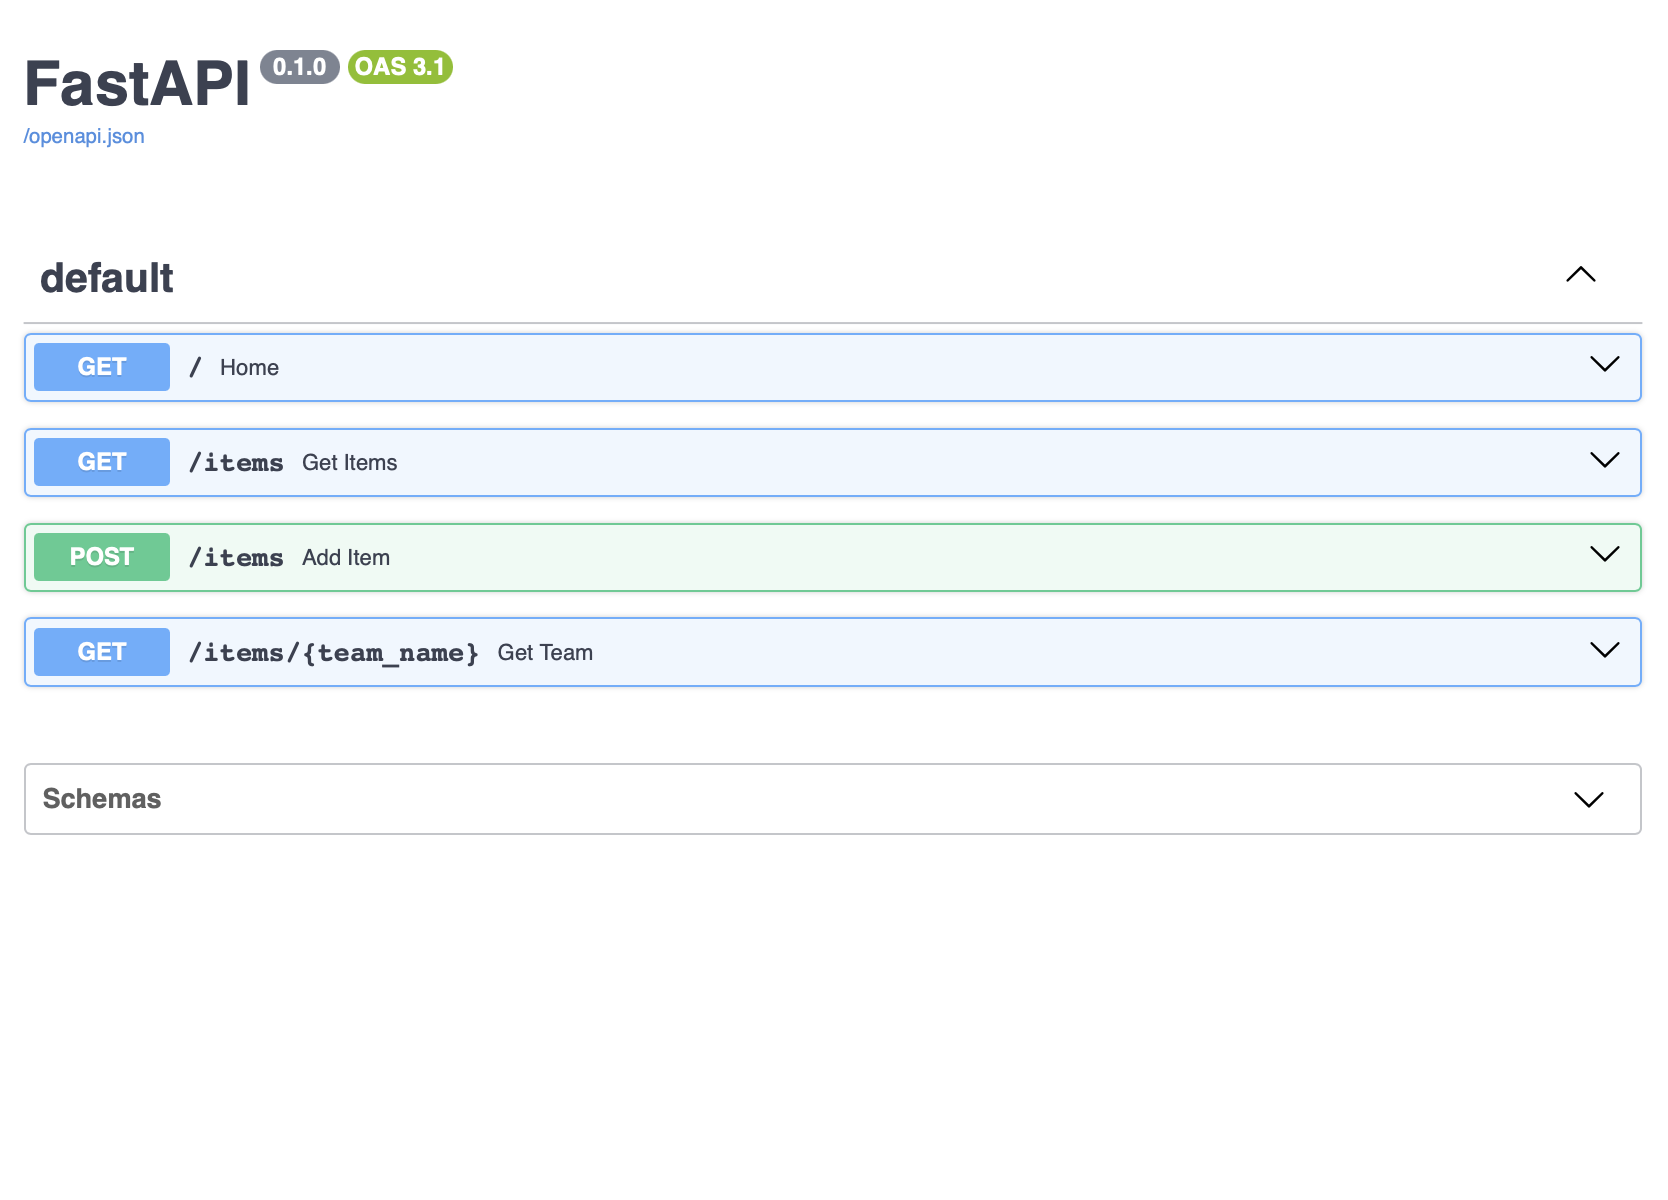

This screenshot shows the FastAPI documentation interface.
It lists all available endpoints and allows users to test the API directly in the browser.

### GET /items endpoint response
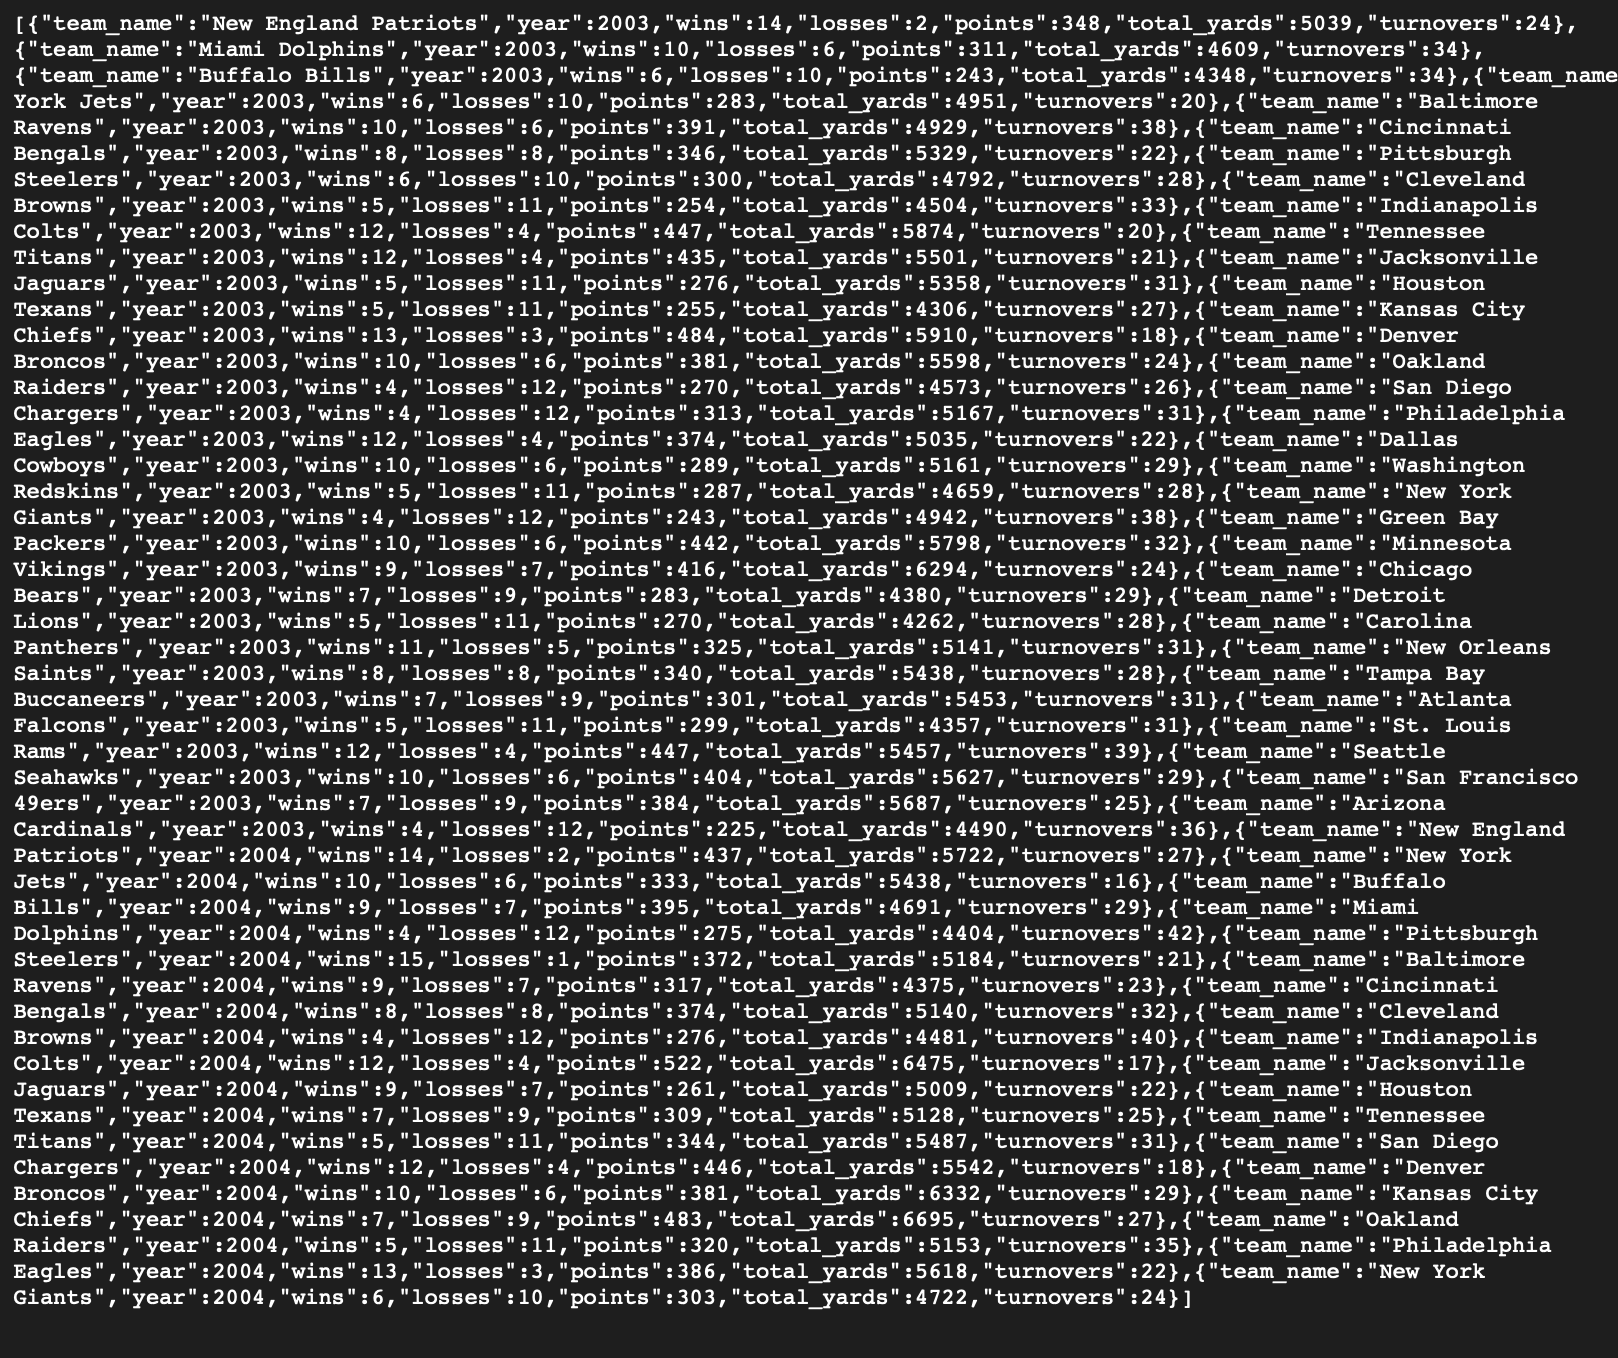

This screenshot shows the GET /items endpoint.
It returns all team-season data from the database, confirming that the API is retrieving data correctly.

### GET /items/{team_name} WITH results
### URL: http://127.0.0.1:8000/items/Steelers
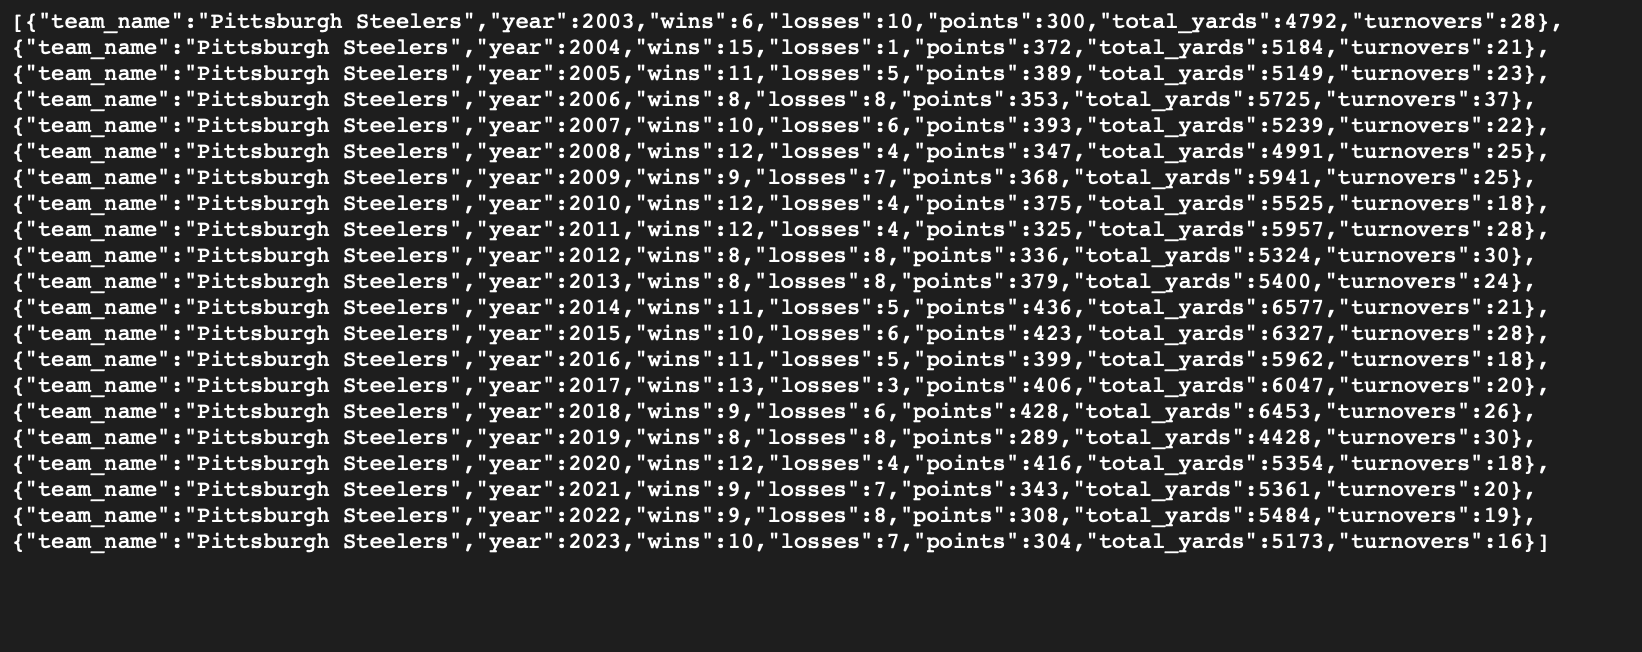

This screenshot shows the GET /items/{team_name} endpoint.
It filters results for a specific team, demonstrating that the API can return targeted data based on user input.